# Feature Integration - Viralytics Projekt
**Teilnehmer 4: Pipeline & Integration**

Dieses Notebook integriert die drei Feature-Dateien von T1, T2, T3 zu einer finalen Feature-Matrix.

**WICHTIG:** Entfernt alle `video_id` Spalten vor dem Speichern!

In [54]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

print("Imports erfolgreich")

Imports erfolgreich


## 2. Dateipfade definieren

In [55]:
# Aktuelles Verzeichnis
current_dir = Path.cwd()
print(f" Aktuelles Arbeitsverzeichnis:")
print(f"   {current_dir}\n")

# Zum Projekt-Root navigieren
if current_dir.name == "notebook":
    project_root = current_dir.parent
    print(" Befinde mich im 'notebook/' Ordner")
else:
    project_root = current_dir
    print(" Befinde mich im Projekt-Root")

print(f" Projekt-Root: {project_root}\n")

# Features-Ordner
features_dir = project_root / "features"

# CSV-Dateien
metadata_file = features_dir / "metadata_features.csv"
audio_file = features_dir / "audio_features.csv"
video_file = features_dir / "video_features.csv"
output_file = features_dir / "FINAL_FEATURE_MATRIX.csv"

print(" Dateipfade:")
print(f"   Features-Ordner: {features_dir}")
print(f"   Metadaten: {metadata_file.name}")
print(f"   Audio: {audio_file.name}")
print(f"   Video: {video_file.name}")
print(f"   Output: {output_file.name}")

# Ordner erstellen falls nicht vorhanden
features_dir.mkdir(parents=True, exist_ok=True)
print(f"\n✓ Features-Ordner bereit")

 Aktuelles Arbeitsverzeichnis:
   /Users/jolanda/Desktop/Study/Project_Algorithmus/Viralitaetsanalyse-main/notebook

 Befinde mich im 'notebook/' Ordner
 Projekt-Root: /Users/jolanda/Desktop/Study/Project_Algorithmus/Viralitaetsanalyse-main

 Dateipfade:
   Features-Ordner: /Users/jolanda/Desktop/Study/Project_Algorithmus/Viralitaetsanalyse-main/features
   Metadaten: metadata_features.csv
   Audio: audio_features.csv
   Video: video_features.csv
   Output: FINAL_FEATURE_MATRIX.csv

✓ Features-Ordner bereit


## 3. Validierung - Dateien prüfen

In [56]:
print(" Validierung:\n")

files = {
    "Metadaten (T1)": metadata_file,
    "Audio (T2)": audio_file,
    "Video (T3)": video_file
}

missing_files = []
for name, filepath in files.items():
    if filepath.exists():
        size_kb = filepath.stat().st_size / 1024
        print(f"✓ {name}: {filepath.name} ({size_kb:.1f} KB)")
    else:
        print(f"✗ {name}: FEHLT - {filepath}")
        missing_files.append(name)

if len(missing_files) == 0:
    print("\n Alle 3 CSV-Dateien vorhanden! Bereit für Integration.")
else:
    print(f"\nWARNUNG: {len(missing_files)} Datei(en) fehlen:")
    for file in missing_files:
        print(f"   {file}")
    print("\n Bitte stellen Sie sicher, dass:")
    print("   1. T1, T2, T3 ihre CSV-Dateien erstellt haben")
    print("   2. Die Dateien im 'features/' Ordner liegen")

 Validierung:

✓ Metadaten (T1): metadata_features.csv (6.6 KB)
✓ Audio (T2): audio_features.csv (82.9 KB)
✓ Video (T3): video_features.csv (20.2 KB)

 Alle 3 CSV-Dateien vorhanden! Bereit für Integration.


## 4. Daten laden

In [57]:
# Nur fortfahren wenn alle Dateien vorhanden
if len(missing_files) > 0:
    print(" Kann nicht fortfahren - Dateien fehlen!")
else:
    print(" Lade Daten...\n")
    
    # Metadaten
    df_metadata = pd.read_csv(metadata_file)
    print(f"Metadaten: {len(df_metadata)} Zeilen, {len(df_metadata.columns)} Spalten")
    
    # Audio
    df_audio = pd.read_csv(audio_file)
    print(f" Audio: {len(df_audio)} Zeilen, {len(df_audio.columns)} Spalten")
    
    # Video
    df_video = pd.read_csv(video_file)
    print(f"Video: {len(df_video)} Zeilen, {len(df_video.columns)} Spalten")
    
    print("\nAlle Daten erfolgreich geladen!")

 Lade Daten...

Metadaten: 200 Zeilen, 6 Spalten
 Audio: 197 Zeilen, 21 Spalten
Video: 197 Zeilen, 13 Spalten

Alle Daten erfolgreich geladen!


In [58]:
print("Metadaten - Erste 3 Zeilen:")
display(df_metadata.head(3))

Metadaten - Erste 3 Zeilen:


,video_id,group,is_viral_proxy,txt_title_has_mention,txt_title_has_question,txt_title_has_hashtag
0,7219026508239686954,top,1,0,0,0
1,7231352152743152942,top,1,0,0,0
2,7236485370542624042,normal,0,0,0,1


In [59]:
print("Audio - Erste 3 Zeilen:")
display(df_audio.head(3))

Audio - Erste 3 Zeilen:


,video_id,bpm,rms_mean,rms_std,spectral_centroid_mean,spectral_centroid_std,spectral_bandwidth_mean,spectral_bandwidth_std,speech_ratio,chroma_var_0,...,chroma_var_2,chroma_var_3,chroma_var_4,chroma_var_5,chroma_var_6,chroma_var_7,chroma_var_8,chroma_var_9,chroma_var_10,chroma_var_11
0,normal_100_likes_22500_id_7516938565066951991,139.674831,0.014903,0.019588,2816.768409,1743.759460,3153.345758,840.977366,0.908403,0.105630,...,0.106298,0.091258,0.089877,0.074280,0.078157,0.089455,0.094581,0.088492,0.105486,0.122652
1,normal_10_likes_83700_id_7546779048593181965,67.999589,0.025423,0.015674,4474.662061,1908.788674,4091.647865,722.189966,0.994350,0.104571,...,0.099630,0.117152,0.135053,0.123853,0.106651,0.107584,0.094656,0.094529,0.088848,0.089647
2,normal_11_likes_30500_id_7559969376590515470,107.666016,0.126814,0.057115,3212.963612,1091.773264,3643.004116,753.319422,0.995717,0.074363,...,0.077808,0.081846,0.083621,0.081858,0.077154,0.078561,0.078145,0.080191,0.076563,0.079554


In [60]:
print("Video - Erste 3 Zeilen:")
display(df_video.head(3))

Video - Erste 3 Zeilen:


,video_id,schnitt_frequenz,durchschnittliche_bewegung,anzahl_frames,video_dauer_sek,ist_person_prominent,ist_tier_sichtbar,avg_objekte_pro_frame,avg_gesichter_pro_frame,dominante_emotion,ist_text_eingeblendet,text_sentiment_compound,video_kategorie
0,top_53_likes_729700_id_7542648831586880823,0.214953,9.150545,107,107.0,1,0,1.8,1.6,happy,0,0.0,Comedy
1,top_45_likes_780200_id_7548598130665622804,0.192308,6.863052,26,26.0,1,0,1.8,1.0,happy,1,0.0,Beauty
2,top_96_likes_365300_id_7560113050100043026,0.290909,5.528583,55,55.0,1,0,1.6,1.2,sad,1,0.0,Beauty


## 5. Video-ID Korrektur

**Problem:** Audio und Video verwenden Dateinamen als video_id, Metadaten verwenden TikTok-IDs.

**Lösung:** Extrahiere TikTok-ID aus Dateinamen mit Regex.

In [61]:
print("=" * 60)
print(" VIDEO_ID KORREKTUR")
print("=" * 60)

import re

# Funktion: Extrahiere TikTok-ID aus Dateinamen
def extract_tiktok_id(filename):
    """
    Extrahiert die TikTok-ID aus Dateinamen wie:
    'normal_100_likes_22600_id_7516938568791009341.mp4'
    to '7516938568791009341'
    """
    # Pattern: alles nach "_id_" bis zum Ende oder vor einem Punkt
    match = re.search(r'_id_(\d+)', str(filename))
    if match:
        return match.group(1)
    
    # Fallback: wenn schon eine Zahl ist
    if str(filename).isdigit():
        return str(filename)
    
    # Sonst: Original zurückgeben
    return str(filename)

# Audio video_id korrigieren
print("\n Audio video_id korrigieren...")
df_audio['video_id_original'] = df_audio['video_id'].copy()  # Backup
df_audio['video_id'] = df_audio['video_id'].apply(extract_tiktok_id)

print(f"  Beispiel Vorher: {df_audio['video_id_original'].iloc[0][:50]}...")
print(f"  Beispiel Nachher: {df_audio['video_id'].iloc[0]}")

# Video video_id korrigieren
print("\n Video video_id korrigieren...")
df_video['video_id_original'] = df_video['video_id'].copy()  # Backup
df_video['video_id'] = df_video['video_id'].apply(extract_tiktok_id)

print(f"  Beispiel Vorher: {df_video['video_id_original'].iloc[0][:50]}...")
print(f"  Beispiel Nachher: {df_video['video_id'].iloc[0]}")

# Metadaten sicherstellen dass video_id String ist
df_metadata['video_id'] = df_metadata['video_id'].astype(str)

print("\n Video-ID Korrektur abgeschlossen!")

 VIDEO_ID KORREKTUR

 Audio video_id korrigieren...
  Beispiel Vorher: normal_100_likes_22500_id_7516938565066951991...
  Beispiel Nachher: 7516938565066951991

 Video video_id korrigieren...
  Beispiel Vorher: top_53_likes_729700_id_7542648831586880823...
  Beispiel Nachher: 7542648831586880823

 Video-ID Korrektur abgeschlossen!


## 6. Konsistenzprüfung

In [62]:
print("\n" + "=" * 60)
print("KONSISTENZPRÜFUNG")
print("=" * 60)

ids_metadata = set(df_metadata['video_id'].astype(str))
ids_audio = set(df_audio['video_id'].astype(str))
ids_video = set(df_video['video_id'].astype(str))
common_ids = ids_metadata & ids_audio & ids_video

print(f"\nVIDEO-ANZAHL:")
print(f" Videos in Metadaten: {len(ids_metadata)}")
print(f" Videos in Audio: {len(ids_audio)}")
print(f" Videos in Video: {len(ids_video)}")
print(f" Gemeinsame Videos: {len(common_ids)}")

if len(common_ids) == 0:
    print("\n FEHLER: KEINE gemeinsamen video_ids gefunden!")
    print("\nErste 3 IDs zum Vergleich:")
    print(f"Metadaten: {list(ids_metadata)[:3]}")
    print(f"Audio: {list(ids_audio)[:3]}")
    print(f"Video: {list(ids_video)[:3]}")
    raise ValueError("Keine Übereinstimmung - Merge nicht möglich!")
    
else:
    print(f"\n ERFOLG! {len(common_ids)} gemeinsame Videos gefunden!")
    
    # Verlorene Videos
    only_metadata = ids_metadata - common_ids
    only_audio = ids_audio - common_ids
    only_video = ids_video - common_ids
    
    if only_metadata:
        print(f"   Nur in Metadaten: {len(only_metadata)} Videos")
    if only_audio:
        print(f"   Nur in Audio: {len(only_audio)} Videos")
    if only_video:
        print(f"   Nur in Video: {len(only_video)} Videos")


KONSISTENZPRÜFUNG

VIDEO-ANZAHL:
 Videos in Metadaten: 200
 Videos in Audio: 197
 Videos in Video: 197
 Gemeinsame Videos: 197

 ERFOLG! 197 gemeinsame Videos gefunden!
   Nur in Metadaten: 3 Videos


## 7. Feature-Integration (Merge)

**Algorithmus:** Hash Join (Pandas)
- Nur Videos mit allen Features werden behalten (inner join)
- Datentyp-Konvertierung zu String für Kompatibilität

In [63]:
print("\n" + "=" * 60)
print("FEATURE-MATRIX ERSTELLEN")
print("=" * 60)

# Datentypen angleichen
print("\n Datentypen angleichen...")
df_metadata['video_id'] = df_metadata['video_id'].astype(str).str.strip()
df_audio['video_id'] = df_audio['video_id'].astype(str).str.strip()
df_video['video_id'] = df_video['video_id'].astype(str).str.strip()
print(" Alle video_id zu String konvertiert")

# Schritt 1: Metadaten + Audio
print("\n" + "="*60)
print("Schritt 1: Metadaten + Audio zusammenführen...")
print("="*60)

merged = pd.merge(
    df_metadata, 
    df_audio, 
    on='video_id', 
    how='inner',
    suffixes=('', '_audio')
)

print(f"✓ Zwischenergebnis: {len(merged)} Zeilen, {len(merged.columns)} Spalten")

if len(merged) == 0:
    print("\n FEHLER: Merge liefert 0 Zeilen!")
    raise ValueError("Merge Schritt 1 fehlgeschlagen")

# Schritt 2: + Video
print("\n" + "="*60)
print("Schritt 2: + Video Features")
print("="*60)

final_matrix = pd.merge(
    merged, 
    df_video, 
    on='video_id', 
    how='inner',
    suffixes=('', '_video')
)

print(f" Finale Matrix: {len(final_matrix)} Zeilen, {len(final_matrix.columns)} Spalten")

if len(final_matrix) == 0:
    print("\n FEHLER: Finale Matrix ist leer!")
    raise ValueError("Merge Schritt 2 fehlgeschlagen")

print("\n MERGE ERFOLGREICH!")


FEATURE-MATRIX ERSTELLEN

 Datentypen angleichen...
 Alle video_id zu String konvertiert

Schritt 1: Metadaten + Audio zusammenführen...
✓ Zwischenergebnis: 197 Zeilen, 27 Spalten

Schritt 2: + Video Features
 Finale Matrix: 197 Zeilen, 40 Spalten

 MERGE ERFOLGREICH!


## 8. KRITISCHE BEREINIGUNG: video_id Spalten entfernen

 Alle video_id-bezogenen Spalten müssen entfernt werden, sonst werden sie zu hunderten Features!

In [64]:
print("\n" + "=" * 60)
print("🧹 KRITISCHE BEREINIGUNG: ID-Spalten entfernen")
print("=" * 60)

print(f"\n📊 VOR Bereinigung:")
print(f"   • Spalten gesamt: {len(final_matrix.columns)}")
print(f"   • Zeilen: {len(final_matrix)}")

# Zeige erste 10 Spalten
print(f"\n   Erste 10 Spalten:")
for i, col in enumerate(list(final_matrix.columns)[:10], 1):
    print(f"      {i:2d}. {col}")

# ====== SCHRITT 1: Identifiziere zu entfernende Spalten ======

cols_to_remove = set()

# 1. Exakt 'video_id'
if 'video_id' in final_matrix.columns:
    cols_to_remove.add('video_id')

# 2. Alle Spalten die 'video_id' enthalten (außer is_viral)
for col in final_matrix.columns:
    col_lower = str(col).lower()
    if 'video_id' in col_lower and 'viral' not in col_lower:
        cols_to_remove.add(col)

# 3. Spalten mit 'original' im Namen (Backup-Spalten)
for col in final_matrix.columns:
    if 'original' in str(col).lower():
        cols_to_remove.add(col)

# 4. Spalten die mit langen Zahlen beginnen (TikTok IDs als Spalten)
for col in final_matrix.columns:
    col_str = str(col)
    # Wenn Spaltenname mit Ziffer beginnt und länger als 15 Zeichen
    if len(col_str) > 0 and col_str[0].isdigit() and len(col_str) > 15:
        cols_to_remove.add(col)

# ====== SCHRITT 2: Entfernen ======

cols_to_remove = list(cols_to_remove)

print(f"\n🗑️ Entferne {len(cols_to_remove)} ID-bezogene Spalten:")
if len(cols_to_remove) <= 10:
    for col in cols_to_remove:
        print(f"   • {col}")
else:
    for col in list(cols_to_remove)[:5]:
        print(f"   • {col}")
    print(f"   ... und {len(cols_to_remove) - 5} weitere")

# Entfernen
final_matrix = final_matrix.drop(columns=cols_to_remove, errors='ignore')

# ====== SCHRITT 3: Verifikation ======

print(f"\n✅ NACH Bereinigung:")
print(f"   • Spalten gesamt: {len(final_matrix.columns)}")
print(f"   • Zeilen: {len(final_matrix)}")

# Erwartete Spalten
expected_features = [
    'bpm', 'rms_mean', 'spectral_centroid_mean',  # Audio
    'schnitt_frequenz', 'durchschnittliche_bewegung',  # Video
    'txt_title_has_mention', 'txt_title_has_question'  # Metadaten
]

print(f"\n📋 Verbleibende Spalten (erste 30):")
remaining_cols = list(final_matrix.columns)
for i, col in enumerate(remaining_cols[:30], 1):
    # Markiere erwartete Spalten
    marker = "✅" if any(exp in str(col) for exp in expected_features) else "  "
    print(f"   {marker} {i:2d}. {col}")

if len(remaining_cols) > 30:
    print(f"   ... und {len(remaining_cols) - 30} weitere")

# ====== SCHRITT 4: Finale Prüfung ======

# Prüfe ob noch video_id Spalten existieren
remaining_id_cols = [col for col in final_matrix.columns 
                      if 'video_id' in str(col).lower()]

if remaining_id_cols:
    print(f"\n⚠️ WARNUNG: Noch {len(remaining_id_cols)} video_id Spalten:")
    for col in remaining_id_cols[:10]:
        print(f"   • {col}")
else:
    print(f"\n✅ Alle video_id Spalten erfolgreich entfernt!")

# Erwartete vs tatsächliche Feature-Anzahl
expected_feature_count = 45  # ~30 numerisch + ~15 durch One-Hot
actual_count = len(final_matrix.columns)

print(f"\n💡 Feature-Anzahl Analyse:")
print(f"   • Erwartet: ~{expected_feature_count} Features")
print(f"   • Tatsächlich: {actual_count} Features")

if actual_count > 100:
    print(f"\n❌ FEHLER: Zu viele Features ({actual_count})!")
    print(f"   Es sind wahrscheinlich noch {actual_count - expected_feature_count} ID-Spalten vorhanden.")
elif actual_count < 20:
    print(f"\n⚠️ WARNUNG: Zu wenige Features ({actual_count})!")
else:
    print(f"\n✅ Feature-Anzahl im erwarteten Bereich!")

print("\n" + "=" * 60)


🧹 KRITISCHE BEREINIGUNG: ID-Spalten entfernen

📊 VOR Bereinigung:
   • Spalten gesamt: 40
   • Zeilen: 197

   Erste 10 Spalten:
       1. video_id
       2. group
       3. is_viral_proxy
       4. txt_title_has_mention
       5. txt_title_has_question
       6. txt_title_has_hashtag
       7. bpm
       8. rms_mean
       9. rms_std
      10. spectral_centroid_mean

🗑️ Entferne 3 ID-bezogene Spalten:
   • video_id_original_video
   • video_id
   • video_id_original

✅ NACH Bereinigung:
   • Spalten gesamt: 37
   • Zeilen: 197

📋 Verbleibende Spalten (erste 30):
       1. group
       2. is_viral_proxy
   ✅  3. txt_title_has_mention
   ✅  4. txt_title_has_question
       5. txt_title_has_hashtag
   ✅  6. bpm
   ✅  7. rms_mean
       8. rms_std
   ✅  9. spectral_centroid_mean
      10. spectral_centroid_std
      11. spectral_bandwidth_mean
      12. spectral_bandwidth_std
      13. speech_ratio
      14. chroma_var_0
      15. chroma_var_1
      16. chroma_var_2
      17. chroma_var_

## 9. Alle Features anzeigen

In [65]:
print("📋 ALLE FEATURES IN DER FINALEN MATRIX:\n")

feature_cols = [col for col in final_matrix.columns]
print(f"Gesamt: {len(feature_cols)} Features\n")

for i, col in enumerate(feature_cols, 1):
    print(f"  {i:3d}. {col}")

📋 ALLE FEATURES IN DER FINALEN MATRIX:

Gesamt: 37 Features

    1. group
    2. is_viral_proxy
    3. txt_title_has_mention
    4. txt_title_has_question
    5. txt_title_has_hashtag
    6. bpm
    7. rms_mean
    8. rms_std
    9. spectral_centroid_mean
   10. spectral_centroid_std
   11. spectral_bandwidth_mean
   12. spectral_bandwidth_std
   13. speech_ratio
   14. chroma_var_0
   15. chroma_var_1
   16. chroma_var_2
   17. chroma_var_3
   18. chroma_var_4
   19. chroma_var_5
   20. chroma_var_6
   21. chroma_var_7
   22. chroma_var_8
   23. chroma_var_9
   24. chroma_var_10
   25. chroma_var_11
   26. schnitt_frequenz
   27. durchschnittliche_bewegung
   28. anzahl_frames
   29. video_dauer_sek
   30. ist_person_prominent
   31. ist_tier_sichtbar
   32. avg_objekte_pro_frame
   33. avg_gesichter_pro_frame
   34. dominante_emotion
   35. ist_text_eingeblendet
   36. text_sentiment_compound
   37. video_kategorie


## 10. Fehlende Werte behandeln

In [66]:
print("Prüfung auf fehlende Werte...\n")

missing = final_matrix.isnull().sum()
missing_features = missing[missing > 0]

if len(missing_features) == 0:
    print("Keine fehlenden Werte!")
else:
    print(f"{len(missing_features)} Features mit fehlenden Werten:\n")
    
    for feature, count in missing_features.items():
        percent = (count / len(final_matrix)) * 100
        print(f" {feature}: {count} ({percent:.1f}%)")
    
    print("\n📋 Imputation durchführen...")
    
    # Numerische Spalten
    numeric_cols = final_matrix.select_dtypes(include=[np.number]).columns
    for col in numeric_cols:
        if final_matrix[col].isnull().any():
            median_val = final_matrix[col].median()
            final_matrix[col].fillna(median_val, inplace=True)
            print(f"  ✓ {col}: Median ({median_val:.2f})")
    
    # Kategorische Spalten
    categorical_cols = final_matrix.select_dtypes(include=['object']).columns
    for col in categorical_cols:
        if final_matrix[col].isnull().any():
            mode_val = final_matrix[col].mode()[0]
            final_matrix[col].fillna(mode_val, inplace=True)
            print(f"  ✓ {col}: Modus ({mode_val})")
    
    print("\n Alle fehlenden Werte behandelt!")

Prüfung auf fehlende Werte...

Keine fehlenden Werte!


## 11. Label übernehmen: is_viral

IS_VIRAL LABEL PRÜFEN UND ÜBERNEHMEN

 'is_viral_proxy' gefunden! Umbenennen zu 'is_viral'...
   Spalte 'is_viral' erstellt

 LABEL-VERTEILUNG:
  • Viral (1):  100 ( 50.8%)
  • Normal (0):  97 ( 49.2%)
  • Gesamt:     197


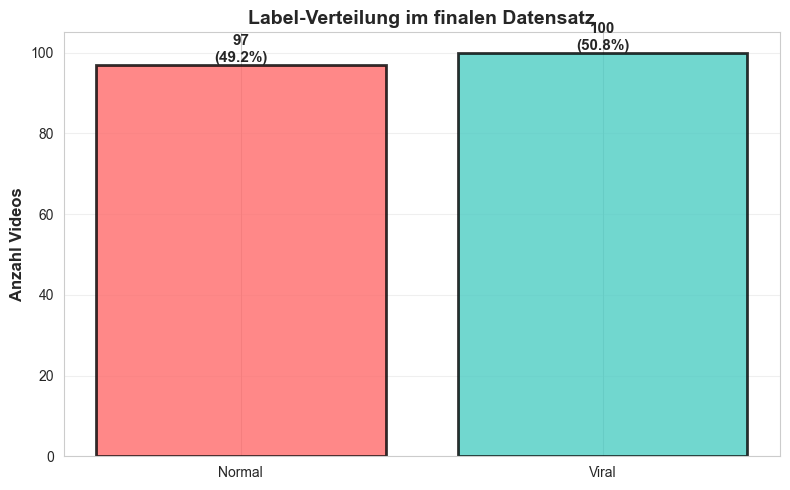


 Label erfolgreich integriert!


In [67]:
print("=" * 60)
print("IS_VIRAL LABEL PRÜFEN UND ÜBERNEHMEN")
print("=" * 60)

# Prüfen ob is_viral bereits existiert
if 'is_viral' in final_matrix.columns:
    print("\n 'is_viral' Label bereits vorhanden!")
    
elif 'is_viral_proxy' in final_matrix.columns:
    print("\n 'is_viral_proxy' gefunden! Umbenennen zu 'is_viral'...")
    final_matrix['is_viral'] = final_matrix['is_viral_proxy']
    print("   Spalte 'is_viral' erstellt")
    
elif 'group' in final_matrix.columns:
    print("\n 'group' Spalte gefunden! Erstelle 'is_viral' daraus...")
    final_matrix['is_viral'] = (final_matrix['group'] == 'top').astype(int)
    print("   Label erstellt: 'top' → 1, 'normal' → 0")
    
else:
    print("\n Kein Label gefunden!")

# Statistik
if 'is_viral' in final_matrix.columns:
    viral_count = final_matrix['is_viral'].sum()
    normal_count = len(final_matrix) - viral_count
    total = len(final_matrix)
    
    print(f"\n LABEL-VERTEILUNG:")
    print(f"  • Viral (1):  {viral_count:3d} ({viral_count/total*100:5.1f}%)")
    print(f"  • Normal (0): {normal_count:3d} ({normal_count/total*100:5.1f}%)")
    print(f"  • Gesamt:     {total:3d}")
    
    # Visualisierung
    fig, ax = plt.subplots(figsize=(8, 5))
    colors = ['#ff6b6b', '#4ecdc4']
    bars = ax.bar(['Normal', 'Viral'], [normal_count, viral_count], 
                   color=colors, alpha=0.8, edgecolor='black', linewidth=2)
    
    ax.set_ylabel('Anzahl Videos', fontsize=12, fontweight='bold')
    ax.set_title('Label-Verteilung im finalen Datensatz', fontsize=14, fontweight='bold')
    ax.grid(axis='y', alpha=0.3)
    
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{int(height)}\n({int(height)/total*100:.1f}%)',
                ha='center', va='bottom', fontsize=11, fontweight='bold')
    
    plt.tight_layout()
    plt.show()
    
    print("\n Label erfolgreich integriert!")

print("=" * 60)

## 12. Finale Feature-Matrix speichern

In [68]:
print("Speichere finale Feature-Matrix...\n")

final_matrix.to_csv(output_file, index=False)

print("=" * 60)
print(" FINALE FEATURE-MATRIX GESPEICHERT")
print("=" * 60)
print(f"\n Datei: {output_file}")
print(f" Größe: {len(final_matrix)} Videos × {len(final_matrix.columns)} Features")
print(f" Dateigröße: {output_file.stat().st_size / 1024:.1f} KB")

# Statistik
print("\n STATISTIK:")
print(f"  • Features (gesamt): {len(final_matrix.columns)}")

if 'is_viral' in final_matrix.columns:
    viral_count = final_matrix['is_viral'].sum()
    total = len(final_matrix)
    print(f"\n  Virale Videos: {viral_count} ({viral_count/total*100:.1f}%)")
    print(f"   Normale Videos: {total - viral_count} ({(total-viral_count)/total*100:.1f}%)")

print("=" * 60)

Speichere finale Feature-Matrix...

 FINALE FEATURE-MATRIX GESPEICHERT

 Datei: /Users/jolanda/Desktop/Study/Project_Algorithmus/Viralitaetsanalyse-main/features/FINAL_FEATURE_MATRIX.csv
 Größe: 197 Videos × 38 Features
 Dateigröße: 86.3 KB

 STATISTIK:
  • Features (gesamt): 38

  Virale Videos: 100 (50.8%)
   Normale Videos: 97 (49.2%)


## 13. Integrations-Bericht erstellen

In [69]:
report_file = features_dir / "integration_report.txt"

with open(report_file, 'w', encoding='utf-8') as f:
    f.write("VIRALYTICS - FEATURE INTEGRATION REPORT\n")
    f.write("=" * 60 + "\n\n")
    
    f.write(f"Datum: {pd.Timestamp.now()}\n\n")
    
    f.write("QUELL-DATEIEN:\n")
    f.write(f"  • Metadaten: {metadata_file.name} ({len(df_metadata)} Videos)\n")
    f.write(f"  • Audio: {audio_file.name} ({len(df_audio)} Videos)\n")
    f.write(f"  • Video: {video_file.name} ({len(df_video)} Videos)\n\n")
    
    f.write("FINALE MATRIX:\n")
    f.write(f"  • Videos: {len(final_matrix)}\n")
    f.write(f"  • Features: {len(final_matrix.columns)}\n\n")
    
    f.write("FEATURE-LISTE:\n")
    for i, col in enumerate(final_matrix.columns, 1):
        f.write(f"  {i:3d}. {col}\n")

print(f" Bericht gespeichert: {report_file}")

 Bericht gespeichert: /Users/jolanda/Desktop/Study/Project_Algorithmus/Viralitaetsanalyse-main/features/integration_report.txt
